# Implementing FastText

##Importing the libraries

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 29.5 MB/s eta 0:00:00


In [2]:
from gensim.models import FastText
from gensim.models.fasttext import compute_ngrams
import matplotlib.pyplot as plt

## Creating documents

In [3]:
documents = [
    "NLP processes text data.",
    "Machine learning processes data.",
    "Deep learning processes text and data."
]

## Tokenizing the documents

In [4]:
sentences = [doc.lower().replace(".", "").split() for doc in documents]

In [5]:
print(sentences)

[['nlp', 'processes', 'text', 'data'], ['machine', 'learning', 'processes', 'data'], ['deep', 'learning', 'processes', 'text', 'and', 'data']]


## Creating a FastText Model

### &nbsp; Initialize FastText with multiple parameters:

*   `sentences` &nbsp; -> &nbsp; **Input text used for training**
*   `vector_size = 10` &nbsp; -> &nbsp; **Dimension of each word embedding vector**
*   `window = 2` &nbsp; -> &nbsp; **Context window size**
*   `min_count = 1` &nbsp; -> &nbsp; **Minimum word frequency to include in vocabulary**
*   `sg = 1` &nbsp; -> &nbsp; **Uses Skip-Gram model (0 = CBOW, 1 = Skip-Gram)**
*   `epochs = 50` &nbsp; -> &nbsp; **Number of training epochs**

In [6]:
fasttext_model = FastText(
    sentences,
    vector_size = 10,
    window = 2,
    min_count = 1,
    workers = 1,
    sg = 1,
    epochs = 50
)

## Visualizing Learned Vectors

In [17]:
print(compute_ngrams(sentences[1][2], min_n = fasttext_model.wv.min_n, max_n = fasttext_model.wv.max_n))

['<pr', 'pro', 'roc', 'oce', 'ces', 'ess', 'sse', 'ses', 'es>', '<pro', 'proc', 'roce', 'oces', 'cess', 'esse', 'sses', 'ses>', '<proc', 'proce', 'roces', 'ocess', 'cesse', 'esses', 'sses>', '<proce', 'proces', 'rocess', 'ocesse', 'cesses', 'esses>']


In [10]:
word_vector = fasttext_model.wv["data"]

In [11]:
print(word_vector)

[ 0.0249455  -0.02677131 -0.00970577 -0.0216243   0.00365162 -0.01775764
 -0.01887397  0.01847737 -0.01933402  0.02673566]


## Finding most similar words to a given word

In [12]:
print(fasttext_model.wv.most_similar("data", topn = 3))

[('deep', 0.7051792144775391), ('machine', 0.2452438771724701), ('learning', -0.01853424869477749)]


## Reducing Dimensions

In [13]:
from sklearn.decomposition import PCA

In [14]:
words = list(fasttext_model.wv.index_to_key)
vectors = [fasttext_model.wv[word] for word in words]

In [15]:
pca = PCA(n_components = 2)
vectors_2d = pca.fit_transform(vectors)

## Graphically Visualizing GloVe

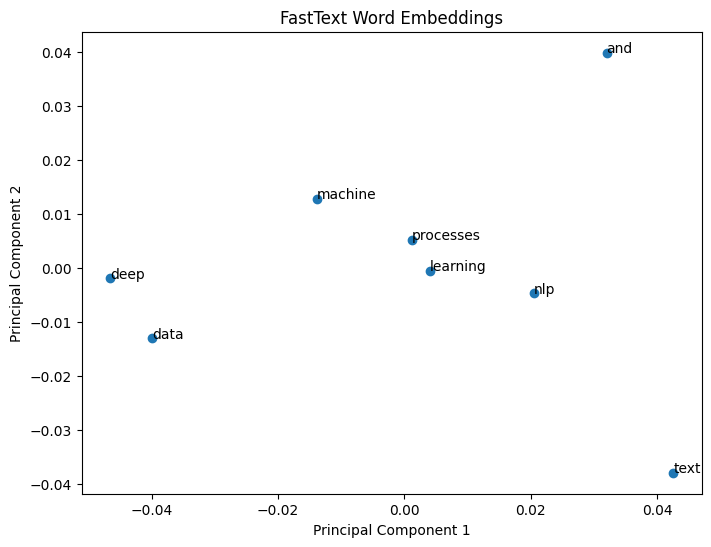

In [16]:
plt.figure(figsize = (8,6))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])

for word, (x, y) in zip(words, vectors_2d):
    plt.annotate(word, (x, y))

plt.title("FastText Word Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()